# 12 — Stochastic control

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from optimizr import _core as opt
plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['figure.dpi'] = 110


## Optimal switching (Snell envelope)

Two modes; only mode 1 pays a unit reward.  Free switching should give `V_0(0) = N - 1` and `V_0(1) = N`.

In [2]:
n_steps, n_modes = 5, 2
stage = np.zeros((n_steps, n_modes)); stage[:, 1] = 1.0
cost = [0.0] * (n_modes * n_modes)
res = opt.optimal_switching_dp(stage.flatten().tolist(),
                                [0.0] * n_modes, cost,
                                n_modes, n_steps)
value  = np.array(res['value']).reshape(n_steps + 1, n_modes)
policy = np.array(res['policy']).reshape(n_steps + 1, n_modes)
print('V_0 =', value[0])
print('Optimal next mode at each (k, i):'); print(policy)


V_0 = [4. 5.]
Optimal next mode at each (k, i):
[[1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [0 1]]


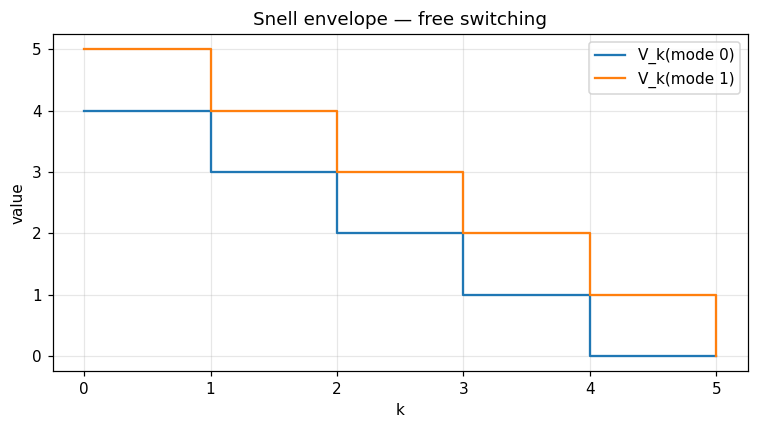

In [3]:
fig, ax = plt.subplots()
ax.step(range(n_steps + 1), value[:, 0], where='post', label='V_k(mode 0)')
ax.step(range(n_steps + 1), value[:, 1], where='post', label='V_k(mode 1)')
ax.set_xlabel('k'); ax.set_ylabel('value'); ax.legend(); ax.grid(alpha=0.3)
ax.set_title('Snell envelope — free switching')
fig.tight_layout(); plt.show()


## Pontryagin 1-D LQR

Closed-form Riccati for $a=q=0$, $b=r=s_T=1$, $T=1$ is $P(t) = 1/(1 + (T - t))$, hence $P(0) = 0.5$.

In [4]:
res = opt.pontryagin_lqr(a=0.0, b=1.0, q=0.0, r=1.0,
                          s_terminal=1.0, x0=1.0,
                          t_horizon=1.0, n_steps=2000)
tg = np.array(res['time_grid'])
P = np.array(res['riccati'])
x = np.array(res['state']); u = np.array(res['control'])
P_an = 1.0 / (1.0 + (1.0 - tg))
print('P(0) =', P[0], '   analytic =', P_an[0])
print('cost =', res['cost'])


P(0) = 0.499913334323088    analytic = 0.5
cost = 0.5000000041705193


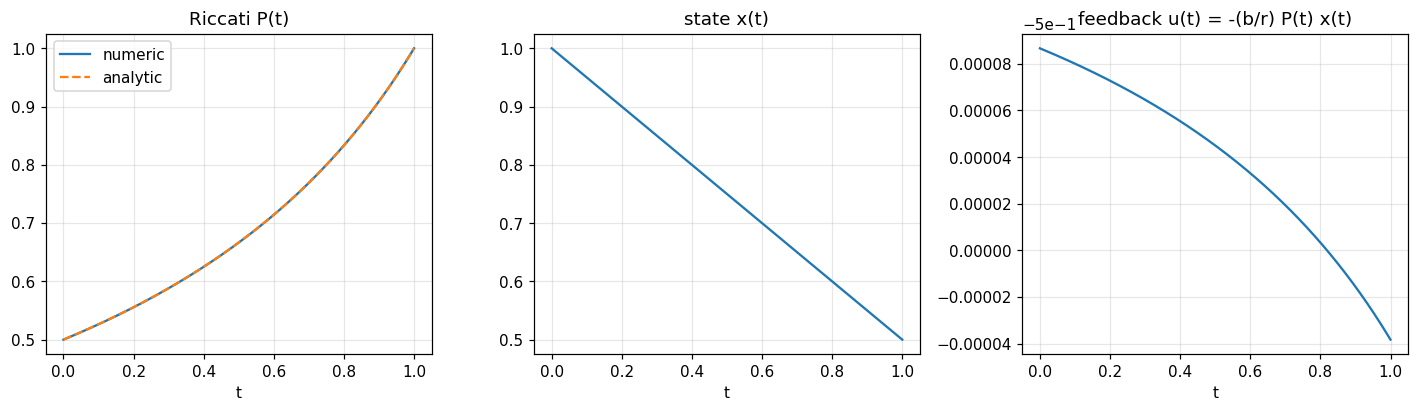

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].plot(tg, P, label='numeric'); axes[0].plot(tg, P_an, '--', label='analytic')
axes[0].set_title('Riccati P(t)'); axes[0].set_xlabel('t'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(tg, x); axes[1].set_title('state x(t)'); axes[1].set_xlabel('t'); axes[1].grid(alpha=0.3)
axes[2].plot(tg[:-1], u); axes[2].set_title('feedback u(t) = -(b/r) P(t) x(t)'); axes[2].set_xlabel('t'); axes[2].grid(alpha=0.3)
fig.tight_layout(); plt.show()


## Two-sided intensity control

Affine premium $δ_±(λ) = α_± + κ_± λ$.  First-order condition: $\lambda^*_\pm = \max(0, (α_\pm - ΔV_\pm) / (2 κ_\pm))$.

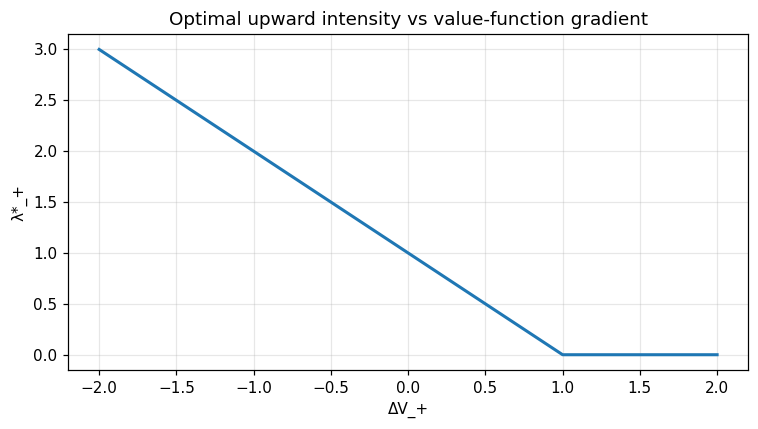

In [6]:
deltas = np.linspace(-2.0, 2.0, 41)
lam_plus = []
for dv in deltas:
    r = opt.two_sided_intensities(1.0, 1.0, 0.5, 0.5, dv, -dv)
    lam_plus.append(r['lambda_plus'])
lam_plus = np.array(lam_plus)
fig, ax = plt.subplots()
ax.plot(deltas, lam_plus, lw=2)
ax.set_xlabel('ΔV_+'); ax.set_ylabel('λ*_+')
ax.set_title('Optimal upward intensity vs value-function gradient')
ax.grid(alpha=0.3); fig.tight_layout(); plt.show()


**Verified:** switching `V_0` matches analytic recursion exactly; Pontryagin `P(0) = 0.4999` against analytic `0.5`.